# imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

/home/al-raisi/miniconda3/envs/sfutilproject/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load model and datasets

In [2]:
model_name = "mistralai/Mistral-7B-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

#harmful prompts
advbench = load_dataset("walledai/AdvBench")
harmful_prompts = advbench['train']['prompt']

#harmless prompts
alpaca = load_dataset("tatsu-lab/alpaca")
harmless_prompts = [entry['instruction'] for entry in alpaca['train']]

#utility prompts
helpsteer = load_dataset("nvidia/HelpSteer")
utility_prompts = [entry['prompt'] for entry in helpsteer['train']]

N = 100
harmful_prompts = harmful_prompts[:N]
harmless_prompts = harmless_prompts[:N]
utility_prompts = utility_prompts[:N]

Loading weights: 100%|██████████| 291/291 [00:30<00:00,  9.50it/s]


# Get activations from all layers 

In [3]:
def get_activations(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [h[:, -1, :].float().cpu().numpy()[0] for h in outputs.hidden_states]

# store all activations from respective dataset
harmful = np.array([get_activations(prompt) for prompt in tqdm(harmful_prompts, desc="harmful")])
harmless = np.array([get_activations(prompt) for prompt in tqdm(harmless_prompts, desc="harmless")])
utility = np.array([get_activations(prompt) for prompt in tqdm(utility_prompts, desc="utility")])

np.save("harmful_activations_mistral.npy", harmful)
np.save("harmless_activations_mistral.npy", harmless)
np.save("utility_activations_mistral.npy", utility)

utility: 100%|██████████| 100/100 [2:17:50<00:00, 82.71s/it]  


# Implement and apply DoM then use cosine similarity on extracted directions

In [4]:
# all have the same size/shape anyways
num_layers = harmful.shape[1]
cosine_similarities = []

#This is same as what was put previously in EDA.ipynb just modified for all layers
for layer in range(num_layers):
    # mean of activations
    harm_mean = harmful[:, layer, :].mean(axis=0)
    help_mean = utility[:, layer, :].mean(axis=0)
    alp_mean = harmless[:, layer, :].mean(axis=0)

    #DoM here extract safety/utility directions 
    refusal_direction = harm_mean - alp_mean
    utility_direction = help_mean - alp_mean

    #for neater results normalize and also recall with cosine similarity that closer to 0 means closer to being independent
    refusal_direction /= np.linalg.norm(refusal_direction)
    utility_direction /= np.linalg.norm(utility_direction)
    cosine_similarities.append(np.dot(refusal_direction, utility_direction))

# Plots and other stuff

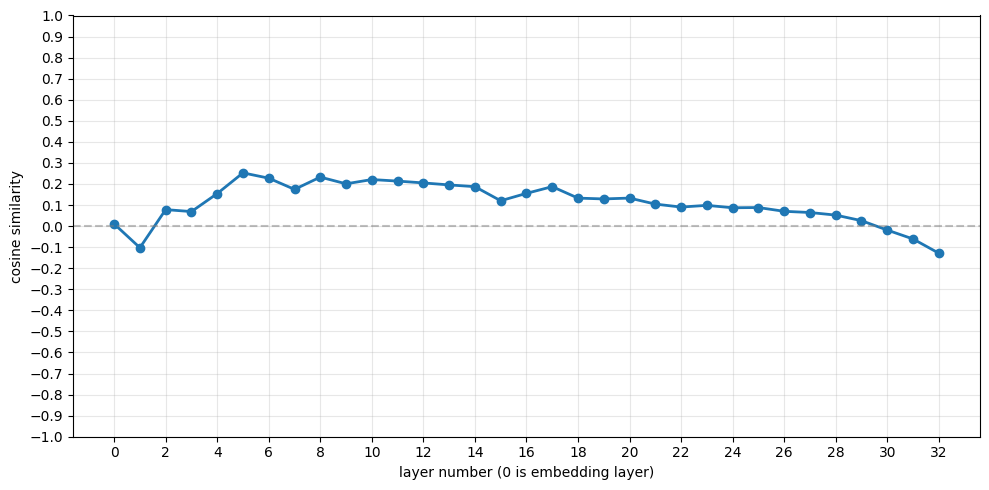

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_layers), cosine_similarities, marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number (0 is embedding layer)")
plt.ylabel("cosine similarity")
plt.xticks(range(0, num_layers, 2))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [6]:
for i, cos_sim in enumerate(cosine_similarities):
    print(f"layer {i} cosine similarity: {cos_sim:.4f}")

layer 0 cosine similarity: 0.0104
layer 1 cosine similarity: -0.1026
layer 2 cosine similarity: 0.0784
layer 3 cosine similarity: 0.0690
layer 4 cosine similarity: 0.1545
layer 5 cosine similarity: 0.2528
layer 6 cosine similarity: 0.2276
layer 7 cosine similarity: 0.1744
layer 8 cosine similarity: 0.2327
layer 9 cosine similarity: 0.2008
layer 10 cosine similarity: 0.2211
layer 11 cosine similarity: 0.2138
layer 12 cosine similarity: 0.2051
layer 13 cosine similarity: 0.1956
layer 14 cosine similarity: 0.1873
layer 15 cosine similarity: 0.1204
layer 16 cosine similarity: 0.1555
layer 17 cosine similarity: 0.1874
layer 18 cosine similarity: 0.1329
layer 19 cosine similarity: 0.1290
layer 20 cosine similarity: 0.1331
layer 21 cosine similarity: 0.1045
layer 22 cosine similarity: 0.0905
layer 23 cosine similarity: 0.0985
layer 24 cosine similarity: 0.0871
layer 25 cosine similarity: 0.0882
layer 26 cosine similarity: 0.0703
layer 27 cosine similarity: 0.0646
layer 28 cosine similarity: 0